In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import kagglehub
from imblearn.over_sampling import SMOTE
from rich.jupyter import display

#Download latest version
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")
kagglehub.login()

print("Path to dataset files:", path)

Path to dataset files: /Users/danniells/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1


In [2]:
print("Arquivos no dataset:", os.listdir(path)) #verifica quais arquivos estão dentro da pasta

Arquivos no dataset: ['Teen_Mental_Health_Dataset.csv']


In [3]:
rota = os.path.join('/Users/danniells/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1', 'Teen_Mental_Health_Dataset.csv') #junta o caminho da pasta com o arquivo

In [4]:
df = pd.read_csv(rota)
df.shape #linhas + colunas

(1200, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [6]:
df.head(8)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0


In [7]:
print("O número máximo de contagens 'null' no DataFrame é: ", df.isnull().sum().max())

O número máximo de contagens 'null' no DataFrame é:  0


In [8]:
ansiedade = 'anxiety_level'
print(df[ansiedade].value_counts())

anxiety_level
6     132
4     131
10    131
8     130
9     124
3     123
2     110
7     109
1     105
5     105
Name: count, dtype: int64


In [9]:
print(df['social_interaction_level'].unique())
print(df['platform_usage'].unique())
print(df['gender'].unique())

['low' 'high' 'medium']
['Instagram' 'TikTok' 'Both']
['male' 'female']


In [10]:
#remove espaços e converte tudo para minusculo
df['gender'] = df['gender'].str.lower().str.strip()
df['platform_usage'] = df['platform_usage'].str.lower().str.strip()
df['social_interaction_level'] = df['social_interaction_level'].str.lower().str.strip()

#Converter os objetos em Int
df['gender'] = df['gender'].map({'male': 1, 'female': 0})
df['platform_usage'] = df['platform_usage'].map({'instagram': 0, 'tiktok': 1, 'both': 2})
df['social_interaction_level'] = df['social_interaction_level'].map({'low': 0, 'medium': 1, 'high': 2})

## EDA (Exploratory Data Analysis)

Text(0, 0.5, 'Nível de Ansiedade')

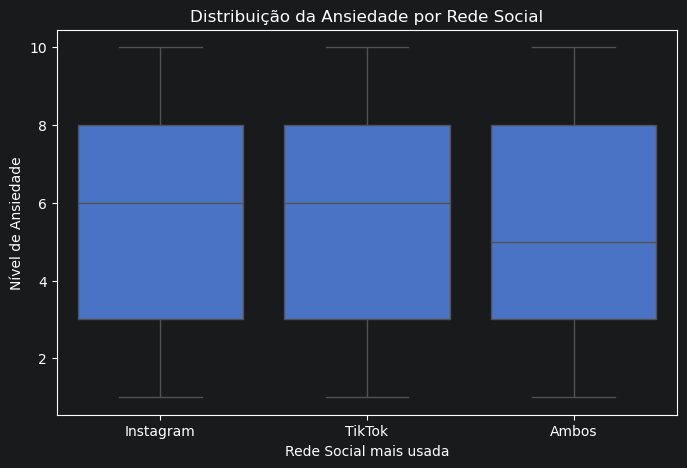

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='platform_usage', y=ansiedade, data=df)

plt.xticks(ticks=[0, 1, 2], labels=['Instagram', 'TikTok', 'Ambos'])

plt.title('Distribuição da Ansiedade por Rede Social')
plt.xlabel('Rede Social mais usada')
plt.ylabel('Nível de Ansiedade')

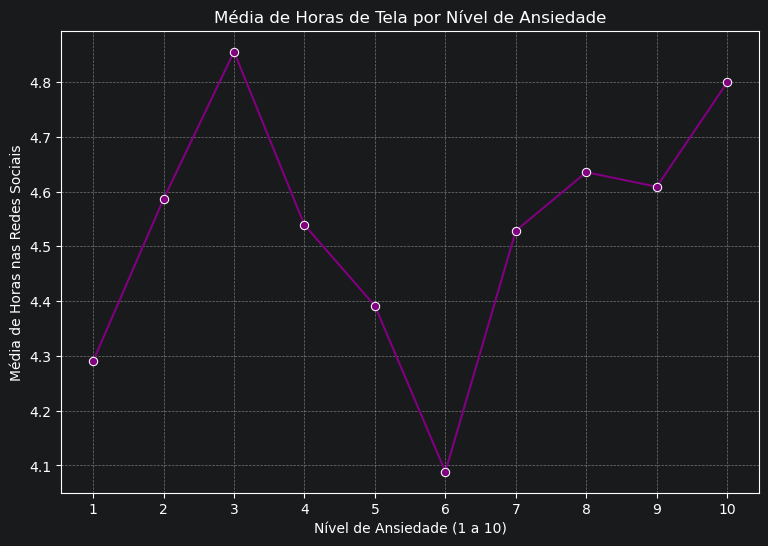

In [27]:
plt.figure(figsize=(9, 6))

# Calcula a média de horas de rede social para cada nível de ansiedade
media_horas_ansiedade = df.groupby(ansiedade)['daily_social_media_hours'].mean().reset_index()

sns.lineplot(x=ansiedade, y='daily_social_media_hours', data=media_horas_ansiedade, marker='o', color='purple')

plt.title('Média de Horas de Tela por Nível de Ansiedade')
plt.xlabel('Nível de Ansiedade (1 a 10)')
plt.ylabel('Média de Horas nas Redes Sociais')
plt.xticks(range(1, 11)) #conta de 1 a 10
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [81]:
print(df['platform_usage'].value_counts())

platform_usage
0    411
1    398
2    391
Name: count, dtype: int64


In [15]:
X = df.drop(ansiedade, axis=1)
y = df[ansiedade]

# Separando Treino e Teste

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Tamanho do Treino: ', len(y_train))
print('Tamanho do Teste: ', len(y_test))
print('\nThe Test labels counts:')
print(y_test.value_counts())

Tamanho do Treino:  960
Tamanho do Teste:  240

The Test labels counts:
anxiety_level
10    36
9     28
4     26
5     26
8     24
6     24
2     23
3     21
7     18
1     14
Name: count, dtype: int64


## Usando o SMOTE
Técnica avançada que ajuda a criar dados para o modelo aprender melhor.
De certa forma, ele inventa dados novos (sintéticos) que são matematicamente prováveis de existir

In [44]:
from imblearn.over_sampling import SMOTE

print('Tamanho do Treino antes: ', len(y_train))

smote = SMOTE(random_state=42, k_neighbors=5) #KNN -> vai funcionar com base na proximidade -> Usa o algoritmo KNN para encontrar os 5 vizinhos mais próximos
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Tamanho do Treino antes: ', len(y_train_smote))

Tamanho do Treino antes:  960
Tamanho do Treino antes:  1080


# Avaliação do Modelo

## Árvore de Decisões

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix #também usado na árvore

modelo_arvore = RandomForestClassifier(n_estimators=100, random_state=42) #vai criar 100 ávores de decisão e fazer uma votação
modelo_arvore.fit(X_train_smote, y_train_smote) #treinando o modelo

y_pred = modelo_arvore.predict(X_test) #previsão usando os dados brutos

In [46]:
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           1       0.07      0.14      0.10        14
           2       0.14      0.13      0.13        23
           3       0.05      0.05      0.05        21
           4       0.20      0.19      0.20        26
           5       0.17      0.15      0.16        26
           6       0.11      0.12      0.12        24
           7       0.08      0.11      0.09        18
           8       0.17      0.17      0.17        24
           9       0.04      0.04      0.04        28
          10       0.19      0.11      0.14        36

    accuracy                           0.12       240
   macro avg       0.12      0.12      0.12       240
weighted avg       0.13      0.12      0.12       240



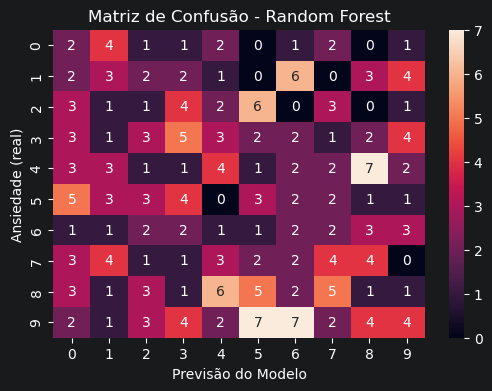

In [47]:
# Desenhando a matriz de confusão
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Ansiedade (real)')
plt.xlabel('Previsão do Modelo')
plt.show()

In [48]:
#Extraindo a importância de cada hábito diário
importancias = pd.DataFrame({
    'Hábito': X.columns,
    'Importancia': modelo_arvore.feature_importances_
}).sort_values(by='Importancia', ascending=False)

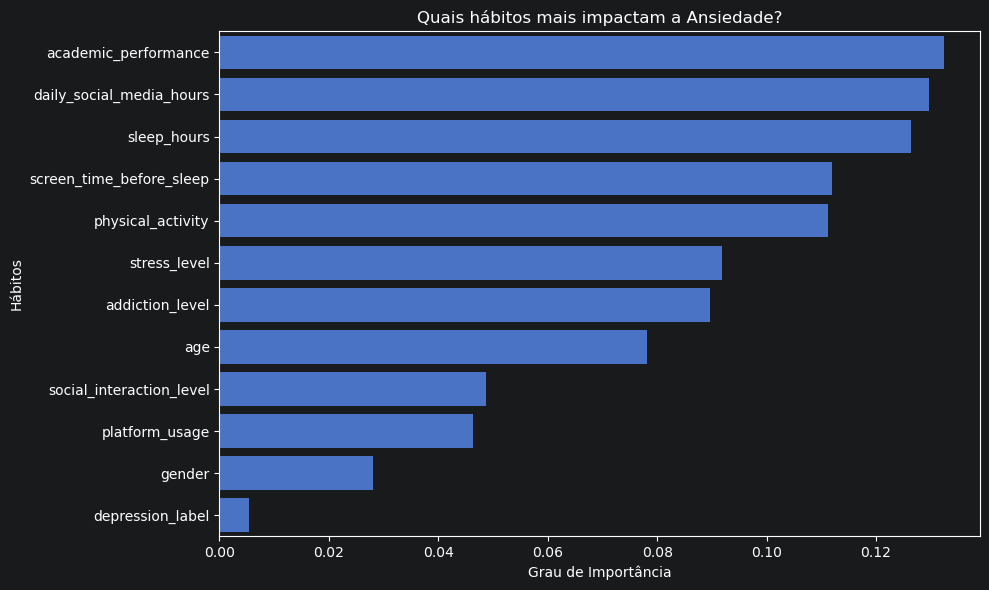

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Hábito', data=importancias)
plt.title('Quais hábitos mais impactam a Ansiedade?')
plt.xlabel('Grau de Importância')
plt.ylabel('Hábitos')
plt.tight_layout()
plt.show()